## Name : Sachin Bhabad
## PRN : 202301040282


# NLP Preprocessing and Text Classification

## Objective
Implement NLP preprocessing techniques and build text classification models using machine learning.

## Learning Outcomes
- Tokenization
- Stopword removal
- Stemming
- Lemmatization
- Text vectorization (CountVectorizer, TF-IDF)
- Classification model training and evaluation

## Dataset
We use the **SMS Spam Collection** dataset (ham vs spam).
Each row has:
- `label`: ham or spam
- `text`: SMS message

In [1]:
# Install packages in notebook if needed
# %pip install pandas numpy scikit-learn nltk seaborn matplotlib

In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

pd.set_option('display.max_colwidth', 140)
sns.set_theme(style='whitegrid')

In [2]:
# Download NLTK resources
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to C:\Users\LOQ
[nltk_data]     15IRX9\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package punkt_tab to C:\Users\LOQ
[nltk_data]     15IRX9\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to C:\Users\LOQ
[nltk_data]     15IRX9\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\LOQ
[nltk_data]     15IRX9\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to C:\Users\LOQ
[nltk_data]     15IRX9\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [3]:
# Load dataset
url = 'https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv'
df = pd.read_csv(url, sep='	', header=None, names=['label', 'text'])

print('Shape:', df.shape)
display(df.head())
display(df['label'].value_counts())

Shape: (5572, 2)


,label,text
0,ham,"Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply ...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives around here though"


label
ham     4825
spam     747
Name: count, dtype: int64

C:\Users\LOQ 15IRX9\AppData\Local\Temp\ipykernel_9192\894387216.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=df, palette='Set2')


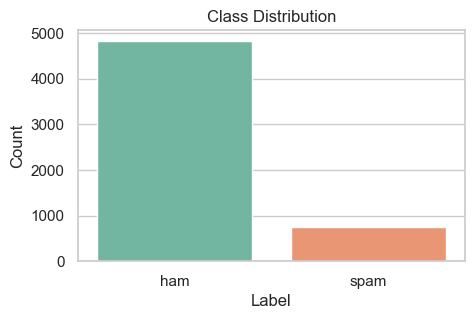

In [4]:
# Encode target: ham=0, spam=1
df['target'] = df['label'].map({'ham': 0, 'spam': 1})

plt.figure(figsize=(5, 3))
sns.countplot(x='label', data=df, palette='Set2')
plt.title('Class Distribution')
plt.xlabel('Label')
plt.ylabel('Count')
plt.show()

In [5]:
# NLP preprocessing components
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

def basic_clean(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def tokenize_text(text):
    return word_tokenize(text)

def remove_stopwords(tokens):
    return [t for t in tokens if t not in stop_words and t.isalpha()]

def stem_tokens(tokens):
    return [stemmer.stem(t) for t in tokens]

def lemmatize_tokens(tokens):
    return [lemmatizer.lemmatize(t) for t in tokens]

In [6]:
# Apply preprocessing step-by-step
df['clean_text'] = df['text'].apply(basic_clean)
df['tokens'] = df['clean_text'].apply(tokenize_text)
df['tokens_nostop'] = df['tokens'].apply(remove_stopwords)
df['stemmed_tokens'] = df['tokens_nostop'].apply(stem_tokens)
df['lemmatized_tokens'] = df['tokens_nostop'].apply(lemmatize_tokens)

df['text_nostop'] = df['tokens_nostop'].apply(lambda x: ' '.join(x))
df['text_stemmed'] = df['stemmed_tokens'].apply(lambda x: ' '.join(x))
df['text_lemmatized'] = df['lemmatized_tokens'].apply(lambda x: ' '.join(x))

display(df[['label', 'text', 'text_nostop', 'text_stemmed', 'text_lemmatized']].head(5))

,label,text,text_nostop,text_stemmed,text_lemmatized
0,ham,"Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...",go jurong point crazy available bugis n great world la e buffet cine got amore wat,go jurong point crazi avail bugi n great world la e buffet cine got amor wat,go jurong point crazy available bugis n great world la e buffet cine got amore wat
1,ham,Ok lar... Joking wif u oni...,ok lar joking wif u oni,ok lar joke wif u oni,ok lar joking wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply ...,free entry wkly comp win fa cup final tkts st may text fa receive entry question std txt rate c apply,free entri wkli comp win fa cup final tkt st may text fa receiv entri question std txt rate c appli,free entry wkly comp win fa cup final tkts st may text fa receive entry question std txt rate c apply
3,ham,U dun say so early hor... U c already then say...,u dun say early hor u c already say,u dun say earli hor u c alreadi say,u dun say early hor u c already say
4,ham,"Nah I don't think he goes to usf, he lives around here though",nah think goes usf lives around though,nah think goe usf live around though,nah think go usf life around though


In [7]:
# Train-test split
X_train_text, X_test_text, y_train, y_test = train_test_split(
    df['text_lemmatized'],
    df['target'],
    test_size=0.2,
    random_state=42,
    stratify=df['target']
)

print('Train size:', X_train_text.shape[0])
print('Test size :', X_test_text.shape[0])

Train size: 4457
Test size : 1115


In [8]:
# Helper function to train and evaluate a model
def train_evaluate(vectorizer, model, X_train_text, X_test_text, y_train, y_test, exp_name):
    X_train = vectorizer.fit_transform(X_train_text)
    X_test = vectorizer.transform(X_test_text)

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    metrics = {
        'experiment': exp_name,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall': recall_score(y_test, y_pred, zero_division=0),
        'f1': f1_score(y_test, y_pred, zero_division=0)
    }

    print(f'\n=== {exp_name} ===')
    print(classification_report(y_test, y_pred, target_names=['ham', 'spam']))

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['ham', 'spam'], yticklabels=['ham', 'spam'])
    plt.title(f'Confusion Matrix - {exp_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

    return metrics


=== Count + Naive Bayes ===
              precision    recall  f1-score   support

         ham       0.98      0.99      0.99       966
        spam       0.96      0.90      0.93       149

    accuracy                           0.98      1115
   macro avg       0.97      0.95      0.96      1115
weighted avg       0.98      0.98      0.98      1115



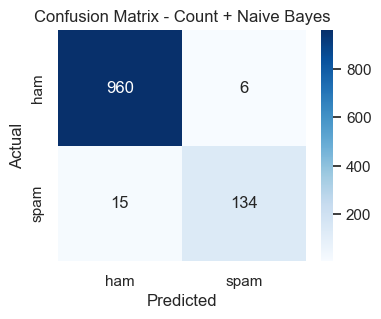


=== Count + Logistic Regression ===
              precision    recall  f1-score   support

         ham       0.98      1.00      0.99       966
        spam       0.99      0.85      0.92       149

    accuracy                           0.98      1115
   macro avg       0.98      0.93      0.95      1115
weighted avg       0.98      0.98      0.98      1115



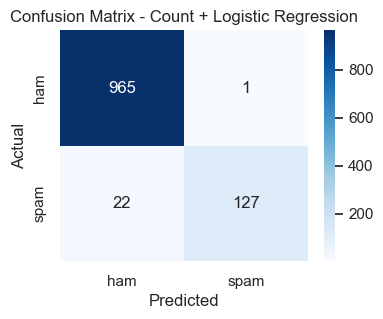


=== TF-IDF + Naive Bayes ===
              precision    recall  f1-score   support

         ham       0.97      1.00      0.98       966
        spam       1.00      0.80      0.89       149

    accuracy                           0.97      1115
   macro avg       0.98      0.90      0.94      1115
weighted avg       0.97      0.97      0.97      1115



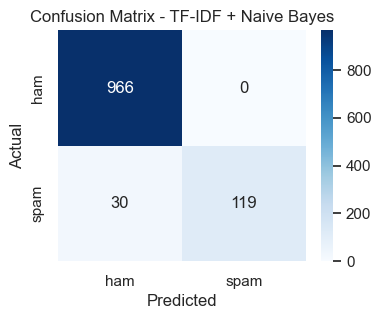


=== TF-IDF + Logistic Regression ===
              precision    recall  f1-score   support

         ham       0.97      1.00      0.99       966
        spam       1.00      0.81      0.89       149

    accuracy                           0.97      1115
   macro avg       0.99      0.90      0.94      1115
weighted avg       0.97      0.97      0.97      1115



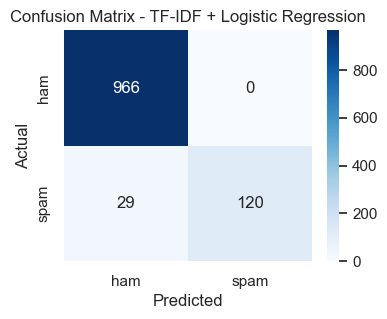

In [9]:
# Run experiments
results = []

count_vec = CountVectorizer(ngram_range=(1, 2), max_features=5000)
tfidf_vec = TfidfVectorizer(ngram_range=(1, 2), max_features=5000)

nb_model = MultinomialNB()
lr_model = LogisticRegression(max_iter=1000)

results.append(train_evaluate(count_vec, nb_model, X_train_text, X_test_text, y_train, y_test, 'Count + Naive Bayes'))
results.append(train_evaluate(count_vec, lr_model, X_train_text, X_test_text, y_train, y_test, 'Count + Logistic Regression'))
results.append(train_evaluate(tfidf_vec, nb_model, X_train_text, X_test_text, y_train, y_test, 'TF-IDF + Naive Bayes'))
results.append(train_evaluate(tfidf_vec, lr_model, X_train_text, X_test_text, y_train, y_test, 'TF-IDF + Logistic Regression'))

In [10]:
# Compare all experiments
results_df = pd.DataFrame(results).sort_values(by='f1', ascending=False).reset_index(drop=True)
display(results_df.style.format({
    'accuracy': '{:.4f}',
    'precision': '{:.4f}',
    'recall': '{:.4f}',
    'f1': '{:.4f}'
}))

best = results_df.iloc[0]
print('Best Pipeline:')
print(f"Experiment: {best['experiment']}")
print(f"F1-score : {best['f1']:.4f}")

,experiment,accuracy,precision,recall,f1
0,Count + Naive Bayes,0.9812,0.9571,0.8993,0.9273
1,Count + Logistic Regression,0.9794,0.9922,0.8523,0.9170
2,TF-IDF + Logistic Regression,0.9740,1.0000,0.8054,0.8922
3,TF-IDF + Naive Bayes,0.9731,1.0000,0.7987,0.8881


Best Pipeline:
Experiment: Count + Naive Bayes
F1-score : 0.9273


## Conclusion
This notebook demonstrates:
- NLP preprocessing (tokenization, stopword removal, stemming, lemmatization)
- Text vectorization (CountVectorizer and TF-IDF)
- Text classification with Naive Bayes and Logistic Regression
- Evaluation using accuracy, precision, recall, F1-score, and confusion matrix

Use the results table to report which vectorizer-model combination performed best for this dataset.